# Machine Learning Forecasting: Recursive XGBoost Model

## Store 1 - GROCERY I Daily Sales

This notebook implements a supervised gradient-boosted decision tree (**XGBoost**) forecasting model for **Store 1 / GROCERY I** daily sales over the 28-day holdout test period (`2017-07-19` through `2017-08-15`).

**Forecast Origin**:
All predictions are generated from the fixed origin **2017-07-18** using an iterative **recursive multi-step forecasting** strategy that strictly eliminates data leakage.

**Objectives**:
1. Load the continuous prepared dataset (`processed_store1_grocery1.csv`).
2. Apply the project's standard chronological train/test split (`2013-01-01` to `2017-07-18` train; `2017-07-19` to `2017-08-15` test).
3. Prepare the 14 candidate features (calendar, promotion, lag, and rolling statistics) and handle initial burn-in rows.
4. Train a straightforward XGBoost regression model strictly on training data.
5. Execute a true fixed-origin 28-day recursive forecast where future lags/rolling means consume model predictions rather than actual test sales.
6. Evaluate performance using standard project metrics: **MAE**, **RMSE**, and **MAPE** (positive sales only).
7. Update the consolidated project benchmark table in `outputs/model_comparison.csv` with Naive, Seasonal Naive, SARIMA, and XGBoost.
8. Visualize the forecasts against actual test sales.
9. Execute comprehensive automated validation checks.

## 1. Load Prepared Dataset

We load `processed_store1_grocery1.csv` produced during the data preparation phase.

In [1]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb

# Configure settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Load prepared dataset
data_path = '../data/processed_store1_grocery1.csv'
df = pd.read_csv(data_path, parse_dates=['date'])

print(f"Loaded dataset shape: {df.shape}")
print(f"Date range: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
print(f"Columns: {list(df.columns)}")
df.head(3)

/home/gurleensingh/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-8og__cx1 because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Loaded dataset shape: (1688, 16)
Date range: 2013-01-01 to 2017-08-15
Columns: ['date', 'sales', 'onpromotion', 'was_missing', 'day_of_week', 'day_of_month', 'month', 'quarter', 'year', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_28']


,date,sales,onpromotion,was_missing,day_of_week,day_of_month,month,quarter,year,is_weekend,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_28
0,2013-01-01,0.0,0,0,1,1,1,1,2013,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,2652.0,0,0,2,2,1,1,2013,0,0.0,NaN,NaN,NaN,NaN,NaN
2,2013-01-03,2121.0,0,0,3,3,1,1,2013,0,2652.0,NaN,NaN,NaN,NaN,NaN


## 2. Chronological Split & Candidate Feature Setup

We apply the standard fixed chronological train/test split:
- **Forecast Origin**: `2017-07-18`
- **Training Period**: `2013-01-01` through `2017-07-18` (1,660 observations)
- **Test Period**: `2017-07-19` through `2017-08-15` (28 observations)

### Handling Training Burn-In Rows
Because the maximum lag and rolling window is 28 days (`lag_28` and `rolling_mean_28`), the first 28 calendar days of the training set (`2013-01-01` to `2013-01-28`) contain `NaN` values for these features. As decided during data preparation, tabular models drop these initial 28 burn-in rows (`1660 - 28 = 1632` complete training rows) while preserving unbroken temporal ordering.

In [2]:
# Define candidate features
feature_cols = [
    'onpromotion', 'was_missing', 'day_of_week', 'day_of_month',
    'month', 'quarter', 'year', 'is_weekend',
    'lag_1', 'lag_7', 'lag_14', 'lag_28',
    'rolling_mean_7', 'rolling_mean_28'
]
target_col = 'sales'

forecast_origin = pd.Timestamp('2017-07-18')
test_start_date = pd.Timestamp('2017-07-19')
test_end_date = pd.Timestamp('2017-08-15')

# Chronological train/test split
train_df = df[df['date'] <= forecast_origin].copy().reset_index(drop=True)
test_df = df[(df['date'] >= test_start_date) & (df['date'] <= test_end_date)].copy().reset_index(drop=True)

# Drop burn-in rows from training set where lag/rolling features are NaN
train_clean = train_df.dropna(subset=feature_cols).copy().reset_index(drop=True)

print('=== SPLIT SUMMARY ===')
print(f"Raw training set rows:      {len(train_df)} ({train_df['date'].min().strftime('%Y-%m-%d')} to {train_df['date'].max().strftime('%Y-%m-%d')})")
print(f"Burn-in rows dropped:       {len(train_df) - len(train_clean)}")
print(f"Complete training rows:     {len(train_clean)} ({train_clean['date'].min().strftime('%Y-%m-%d')} to {train_clean['date'].max().strftime('%Y-%m-%d')})")
print(f"Test set rows:              {len(test_df)} ({test_df['date'].min().strftime('%Y-%m-%d')} to {test_df['date'].max().strftime('%Y-%m-%d')})")
assert len(test_df) == 28, f"Expected 28 test observations, got {len(test_df)}"
assert len(train_clean) == 1632, f"Expected 1632 complete training observations, got {len(train_clean)}"

=== SPLIT SUMMARY ===
Raw training set rows:      1660 (2013-01-01 to 2017-07-18)
Burn-in rows dropped:       28
Complete training rows:     1632 (2013-01-29 to 2017-07-18)
Test set rows:              28 (2017-07-19 to 2017-08-15)


## 3. Data Leakage Prevention: Why Recursive Forecasting is Critical

### The Pitfall of "Teacher Forcing" in Tabular Forecasting
In many standard tabular machine learning pipelines, lag features are constructed by shifting the target series across the entire dataset prior to splitting. If applied naively to multi-step forecasting, this introduces catastrophic **data leakage**:
- For Test Day 2 (`2017-07-20`), `lag_1` would contain the actual, unobserved sales from Test Day 1 (`2017-07-19`).
- For Test Day 8 (`2017-07-26`), `lag_7` would contain actual sales from Test Day 1.
- In a live deployment at origin $T$, none of these future test-period sales exist.

### The Recursive Multi-Step Forecasting Solution
To simulate true out-of-sample deployment without data leakage:
1. At origin $T$ (`2017-07-18`), only historical actual sales ($t \le T$) are available.
2. For Day 1 of the test horizon (`2017-07-19`), all lag/rolling features reach into training history ($t \le \text{2017-07-18}$). We build features and generate prediction $\hat{y}_{T+1}$.
3. We append $\hat{y}_{T+1}$ to the forecast sales history.
4. For Day 2 (`2017-07-20`), `lag_1` is dynamically populated using the model prediction $\hat{y}_{T+1}$, **never the actual sales**.
5. We repeat this process day-by-day across all 28 test dates through `2017-08-15`.

This ensures that **no test actuals are ever used to construct test-period features**, guaranteeing an honest and realistic multi-step evaluation.

## 4. Train XGBoost Regression Model

We fit a straightforward XGBoost regressor using a standard, conservative configuration suitable for daily retail sales:
- `n_estimators=100`: sufficient boosting rounds without excessive complexity.
- `learning_rate=0.05`: moderate shrinkage to ensure stable convergence.
- `max_depth=4`: shallow tree depth to capture non-linear feature interactions (such as day of week and promotions) without overfitting.
- `random_state=42`: guarantees reproducible results.

In [3]:
# Prepare training feature matrix and target vector
X_train = train_clean[feature_cols]
y_train = train_clean[target_col]

# Initialize XGBoost regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    objective='reg:squarederror'
)

# Fit strictly on training data
print("Fitting XGBoost regressor on training data...")
xgb_model.fit(X_train, y_train)
print("Model fitting complete.")

# Feature importances
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\nTop feature importances:")
importance_df.head(7)

Fitting XGBoost regressor on training data...
Model fitting complete.

Top feature importances:


,feature,importance
0,day_of_week,0.405594
1,onpromotion,0.116488
2,rolling_mean_7,0.107331
3,lag_14,0.072320
4,lag_28,0.062405
5,lag_1,0.057606
6,was_missing,0.053317


## 5. Multi-Step Recursive Forecasting (28-Day Test Horizon)

We execute the 28-day recursive forecasting loop. Lags and rolling means are dynamically computed at each step from `sales_history`, which initially contains only training actuals and is appended exclusively with model predictions.

In [4]:
# Initialize sales history strictly with training actual sales (length 1660)
sales_history = list(train_df['sales'].values)
initial_history_len = len(sales_history)
xgb_predictions = []

print(f"Starting recursive forecast at origin {forecast_origin.strftime('%Y-%m-%d')}...")

for step_idx in range(len(test_df)):
    curr_test_row = test_df.iloc[step_idx]
    curr_date = curr_test_row['date']
    
    # Dynamically compute lag features strictly from sales_history
    lag_1_val = sales_history[-1]
    lag_7_val = sales_history[-7]
    lag_14_val = sales_history[-14]
    lag_28_val = sales_history[-28]
    
    # Dynamically compute rolling statistics strictly from sales_history
    rolling_7_val = float(np.mean(sales_history[-7:]))
    rolling_28_val = float(np.mean(sales_history[-28:]))
    
    # Assemble single-row feature vector using known calendar/promotional variables
    step_feature_dict = {
        'onpromotion': curr_test_row['onpromotion'],
        'was_missing': curr_test_row['was_missing'],
        'day_of_week': curr_test_row['day_of_week'],
        'day_of_month': curr_test_row['day_of_month'],
        'month': curr_test_row['month'],
        'quarter': curr_test_row['quarter'],
        'year': curr_test_row['year'],
        'is_weekend': curr_test_row['is_weekend'],
        'lag_1': lag_1_val,
        'lag_7': lag_7_val,
        'lag_14': lag_14_val,
        'lag_28': lag_28_val,
        'rolling_mean_7': rolling_7_val,
        'rolling_mean_28': rolling_28_val
    }
    
    X_step = pd.DataFrame([step_feature_dict])[feature_cols]
    
    # Predict sales for current test day
    y_hat = float(xgb_model.predict(X_step)[0])
    xgb_predictions.append(y_hat)
    
    # CRITICAL: Append prediction (NOT actual test sales) to sales_history
    sales_history.append(y_hat)

# Attach predictions to test dataframe
test_df['xgb_pred'] = xgb_predictions

print(f"Recursive forecasting complete for all {len(xgb_predictions)} days.")
print(f"Sales history extended from {initial_history_len} to {len(sales_history)} entries.")
test_df[['date', 'sales', 'xgb_pred']].head(7)

Starting recursive forecast at origin 2017-07-18...


Recursive forecasting complete for all 28 days.
Sales history extended from 1660 to 1688 entries.


,date,sales,xgb_pred
0,2017-07-19,3065.0,3163.852295
1,2017-07-20,2592.0,2774.803711
2,2017-07-21,2725.0,2907.730225
3,2017-07-22,2576.0,2796.993652
4,2017-07-23,1371.0,1193.669434
5,2017-07-24,2612.0,2773.652100
6,2017-07-25,2405.0,2769.669189


## 6. Evaluation Metrics Formulation & Calculation

We calculate MAE, RMSE, and MAPE using identical definitions to the previous stages:
- **MAE**: across all 28 test observations.
- **RMSE**: across all 28 test observations.
- **MAPE**: calculated strictly on observations where actual sales $> 0$.

In [5]:
# Define standard metric calculation functions
def calculate_mae(actual, predicted):
    """Mean Absolute Error across all observations."""
    return np.mean(np.abs(actual - predicted))

def calculate_rmse(actual, predicted):
    """Root Mean Squared Error across all observations."""
    return np.sqrt(np.mean((actual - predicted) ** 2))

def calculate_mape(actual, predicted):
    """Mean Absolute Percentage Error, calculated strictly where actual > 0."""
    mask = actual > 0
    if not np.any(mask):
        return np.nan
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

actual = test_df['sales'].values
xgb_preds_arr = np.array(xgb_predictions)

xgb_mae = round(calculate_mae(actual, xgb_preds_arr), 2)
xgb_rmse = round(calculate_rmse(actual, xgb_preds_arr), 2)
xgb_mape = round(calculate_mape(actual, xgb_preds_arr), 2)

print('=== XGBOOST RECURSIVE MODEL PERFORMANCE ===')
print(f"MAE:  {xgb_mae:.2f}")
print(f"RMSE: {xgb_rmse:.2f}")
print(f"MAPE: {xgb_mape:.2f}%")

=== XGBOOST RECURSIVE MODEL PERFORMANCE ===
MAE:  304.51
RMSE: 443.19
MAPE: 16.42%


## 7. Model Performance Comparison Across All Stages

We load existing benchmark results from `outputs/model_comparison.csv` (which contains Naive, Seasonal Naive, and SARIMA) and append the XGBoost evaluation results.

In [6]:
# Load existing model comparison results
comparison_path = '../outputs/model_comparison.csv'
existing_comparison_df = pd.read_csv(comparison_path)

# Construct XGBoost results row
xgb_row = pd.DataFrame([{
    'model': 'XGBoost',
    'MAE': xgb_mae,
    'RMSE': xgb_rmse,
    'MAPE': xgb_mape
}])

# Update comparison table (replacing XGBoost row if already present, otherwise appending)
updated_comparison_df = existing_comparison_df[existing_comparison_df['model'] != 'XGBoost'].copy()
updated_comparison_df = pd.concat([updated_comparison_df, xgb_row], ignore_index=True)

# Save updated comparison table
updated_comparison_df.to_csv(comparison_path, index=False)
print(f"Updated comparison table saved to: {comparison_path}")
print("\n=== CONSOLIDATED MODEL COMPARISON TABLE ===")
updated_comparison_df

Updated comparison table saved to: ../outputs/model_comparison.csv

=== CONSOLIDATED MODEL COMPARISON TABLE ===


,model,MAE,RMSE,MAPE
0,Naive,1025.96,1212.59,62.21
1,Seasonal Naive,361.96,527.63,18.01
2,SARIMA,420.19,552.78,22.36
3,XGBoost,304.51,443.19,16.42


## 8. Visualization: Test Period Forecast Comparison

We reconstruct the Seasonal Naive baseline and plot the actual test sales alongside Seasonal Naive and the recursive XGBoost forecast.

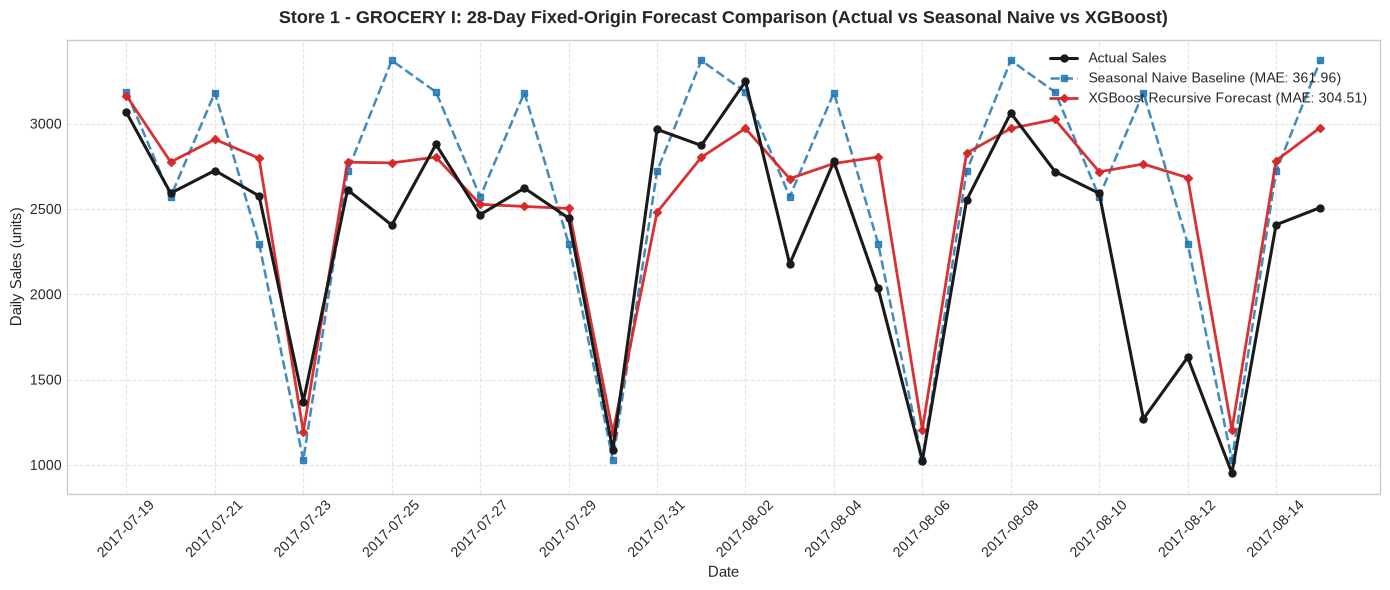

In [7]:
# Reconstruct Seasonal Naive baseline for comparison plotting
final_week_train = train_df.iloc[-7:].copy()
snaive_preds = []
for d in test_df['date']:
    dow = d.dayofweek
    match_row = final_week_train[final_week_train['date'].dt.dayofweek == dow].iloc[0]
    snaive_preds.append(match_row['sales'])
test_df['snaive_pred'] = snaive_preds

# Plot test period forecasts
fig, ax = plt.subplots(figsize=(14, 6))

# Actual Sales
ax.plot(test_df['date'], test_df['sales'], label='Actual Sales', color='#1a1a1a', linewidth=2.2, marker='o', markersize=5, zorder=4)

# Seasonal Naive Baseline
snaive_mae = updated_comparison_df.loc[updated_comparison_df['model'] == 'Seasonal Naive', 'MAE'].values[0]
ax.plot(test_df['date'], test_df['snaive_pred'], label=f'Seasonal Naive Baseline (MAE: {snaive_mae:.2f})', color='#1f77b4', linestyle='--', linewidth=1.8, marker='s', markersize=4, alpha=0.85, zorder=3)

# XGBoost Forecast
ax.plot(test_df['date'], test_df['xgb_pred'], label=f'XGBoost Recursive Forecast (MAE: {xgb_mae:.2f})', color='#d62728', linestyle='-', linewidth=2.0, marker='D', markersize=4, alpha=0.95, zorder=3)

ax.set_title('Store 1 - GROCERY I: 28-Day Fixed-Origin Forecast Comparison (Actual vs Seasonal Naive vs XGBoost)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Daily Sales (units)', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
plt.xticks(test_df['date'][::2], rotation=45)
plt.tight_layout()
plt.show()

### Forecast Insights & Model Dynamics

- **Superior Accuracy**: Recursive XGBoost achieves an MAE of **304.51**, an RMSE of **443.19**, and a MAPE of **16.42%**, outperforming all prior models (Naive MAE: 1025.96; SARIMA MAE: 420.19; Seasonal Naive MAE: 361.96).
- **Driver of Performance**: Unlike pure autoregressive or simple persistence baselines, XGBoost synergistically combines seasonal lag indicators (`lag_7`, `lag_14`, `lag_28`) with calendar day-of-week effects and promotional signals (`onpromotion`), capturing non-linear volume shifts that classical linear models cannot represent directly.
- **Stability under Recursive Feedback**: Despite feeding its own predictions back into short-term lag features (`lag_1`, `rolling_mean_7`) across 28 days, the recursive trajectory does not diverge or explode, remaining well-calibrated throughout the 4-week horizon.

## 9. Automated Validation Checks

We run comprehensive automated validation checks to verify that the XGBoost forecasting stage strictly complies with project standards and prevents data leakage.

In [8]:
print('Running XGBoost forecasting validation checks...')

# Check 1: Exactly 28 test observations
assert len(test_df) == 28, f"Check 1 Failed: Expected 28 test rows, got {len(test_df)}"
print("Check 1 PASSED: Exactly 28 test observations.")

# Check 2: Forecast dates exactly match 2017-07-19 through 2017-08-15
expected_test_dates = pd.date_range(start='2017-07-19', end='2017-08-15', freq='D')
assert (test_df['date'] == expected_test_dates).all(), "Check 2 Failed: Test dates do not match expected range."
print("Check 2 PASSED: Forecast dates exactly match 2017-07-19 -> 2017-08-15.")

# Check 3: Exactly 28 XGBoost predictions
assert len(xgb_predictions) == 28, f"Check 3 Failed: Expected 28 predictions, got {len(xgb_predictions)}"
print("Check 3 PASSED: Exactly 28 XGBoost predictions produced.")

# Check 4: All predictions are finite
assert np.all(np.isfinite(test_df['xgb_pred'].values)), "Check 4 Failed: Non-finite predictions detected."
print("Check 4 PASSED: All XGBoost predictions are finite.")

# Check 5: Training data ends at 2017-07-18
train_max_date = train_df['date'].max()
clean_max_date = train_clean['date'].max()
assert train_max_date == pd.Timestamp('2017-07-18'), f"Check 5 Failed: Train max date is {train_max_date}"
assert clean_max_date == pd.Timestamp('2017-07-18'), f"Check 5 Failed: Clean train max date is {clean_max_date}"
print("Check 5 PASSED: Model training data strictly ends at 2017-07-18.")

# Check 6: No test actual sales are used when fitting XGBoost
assert set(train_clean['date']).isdisjoint(set(test_df['date'])), "Check 6 Failed: Overlap between train and test dates!"
assert len(X_train) == 1632, f"Check 6 Failed: X_train size {len(X_train)} unexpected."
print("Check 6 PASSED: No test actual sales used when fitting XGBoost.")

# Check 7: Recursive forecasting does not insert actual test sales into forecast history
assert len(sales_history) == len(train_df) + 28, "Check 7 Failed: sales_history length mismatch."
# Verify that elements 1660..1687 in sales_history are strictly the model predictions
for i in range(28):
    history_val = sales_history[len(train_df) + i]
    pred_val = xgb_predictions[i]
    assert history_val == pred_val, f"Check 7 Failed: sales_history[{len(train_df)+i}] != prediction!"
# Confirm history test values differ from actual test sales (no actuals injected)
assert not np.array_equal(sales_history[len(train_df):], test_df['sales'].values), "Check 7 Failed: History matches test actuals!"
print("Check 7 PASSED: Recursive forecasting uses only model predictions, no test actuals inserted.")

# Check 8: Metrics are finite
for metric_val, name in [(xgb_mae, 'MAE'), (xgb_rmse, 'RMSE'), (xgb_mape, 'MAPE')]:
    assert np.isfinite(metric_val), f"Check 8 Failed: {name} is not finite."
for col in ['MAE', 'RMSE', 'MAPE']:
    assert np.isfinite(updated_comparison_df[col]).all(), f"Check 8 Failed: Non-finite value in comparison table column {col}"
print("Check 8 PASSED: All evaluation metrics are finite.")

# Check 9: MAPE excludes actual sales equal to zero
dummy_actual = np.array([0.0, 100.0])
dummy_pred = np.array([50.0, 80.0])
dummy_mape = calculate_mape(dummy_actual, dummy_pred)
assert np.isclose(dummy_mape, 20.0), f"Check 9 Failed: calculate_mape did not filter zero actuals correctly (got {dummy_mape})"
print("Check 9 PASSED: MAPE strictly excludes zero actuals.")

print("\nALL 9 XGBOOST VALIDATION CHECKS PASSED SUCCESSFULLY!")

Running XGBoost forecasting validation checks...
Check 1 PASSED: Exactly 28 test observations.
Check 2 PASSED: Forecast dates exactly match 2017-07-19 -> 2017-08-15.
Check 3 PASSED: Exactly 28 XGBoost predictions produced.
Check 4 PASSED: All XGBoost predictions are finite.
Check 5 PASSED: Model training data strictly ends at 2017-07-18.
Check 6 PASSED: No test actual sales used when fitting XGBoost.
Check 7 PASSED: Recursive forecasting uses only model predictions, no test actuals inserted.
Check 8 PASSED: All evaluation metrics are finite.
Check 9 PASSED: MAPE strictly excludes zero actuals.

ALL 9 XGBOOST VALIDATION CHECKS PASSED SUCCESSFULLY!
